In [1]:
import sys
sys.path.append("/Users/hnq/Desktop/licenta/cod_plante")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import models
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import time
from pathlib import Path
from src.data_loaders import get_dataloaders, get_class_names, get_device

train_loader, val_loader = get_dataloaders()
class_names = get_class_names()
device = get_device()

print(f"Device: {device}")
print(f"Number of classes: {len(class_names)}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Device: mps
Number of classes: 38
Train batches: 1358
Val batches: 340


In [2]:
model = models.efficientnet_b4(weights='DEFAULT')

print("Original classifier:")
print(model.classifier)

num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 38)

print("\nNew classifier:")
print(model.classifier)

model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

Original classifier:
Sequential(
  (0): Dropout(p=0.4, inplace=True)
  (1): Linear(in_features=1792, out_features=1000, bias=True)
)

New classifier:
Sequential(
  (0): Dropout(p=0.4, inplace=True)
  (1): Linear(in_features=1792, out_features=38, bias=True)
)

Total parameters: 17,616,750


In [3]:
for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters (Phase 1): {trainable_params:,}")
print(f"Frozen parameters: {total_params - trainable_params:,}")
print(f"Trainable percentage: {100 * trainable_params / total_params:.2f}%")

Total parameters: 17,616,750
Trainable parameters (Phase 1): 68,134
Frozen parameters: 17,548,616
Trainable percentage: 0.39%


In [4]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / total, 100.0 * correct / total


def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return running_loss / total, 100.0 * correct / total


print("Training and validation functions defined")

Training and validation functions defined


In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

PHASE1_EPOCHS = 5

train_losses, train_accs = [], []
val_losses, val_accs = [], []

print("PHASE 1: Training classifier only (frozen backbone)")

start_time = time.time()
for epoch in range(1, PHASE1_EPOCHS + 1):
    epoch_start = time.time()
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    
    scheduler.step(val_loss)
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    epoch_time = time.time() - epoch_start
    print(f"Phase 1 Epoch {epoch}/{PHASE1_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% | "
          f"Time: {epoch_time:.1f}s")

phase1_time = time.time() - start_time
print(f"\nPhase 1 completed in {phase1_time/60:.1f} minutes")

PHASE 1: Training classifier only (frozen backbone)


Training:   0%|          | 0/1358 [00:00<?, ?it/s]

Validation:   0%|          | 0/340 [00:00<?, ?it/s]

Phase 1 Epoch 1/5 | Train Loss: 2.8090 Acc: 37.82% | Val Loss: 2.3421 Acc: 53.11% | Time: 513.1s


Training:   0%|          | 0/1358 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/340 [00:00<?, ?it/s]

Phase 1 Epoch 4/5 | Train Loss: 1.2710 Acc: 73.30% | Val Loss: 1.3475 Acc: 72.67% | Time: 495.1s


Training:   0%|          | 0/1358 [00:00<?, ?it/s]

Validation:   0%|          | 0/340 [00:00<?, ?it/s]

Phase 1 Epoch 5/5 | Train Loss: 1.1100 Acc: 75.82% | Val Loss: 1.0932 Acc: 77.32% | Time: 502.7s

Phase 1 completed in 41.6 minutes


In [6]:
for param in model.parameters():
    param.requires_grad = True

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters (Phase 2): {trainable_params:,}")

optimizer = optim.Adam(model.parameters(), lr=1e-5)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print("Optimizer reconfigured for fine-tuning, lr = 1e-5")

Trainable parameters (Phase 2): 17,616,750
Optimizer reconfigured for fine-tuning, lr = 1e-5


In [7]:
PHASE2_EPOCHS = 20

MODEL_PATH = Path("/Users/hnq/Desktop/licenta/cod_plante/models")
MODEL_PATH.mkdir(exist_ok=True)
BEST_MODEL_FILE = MODEL_PATH / "n04_efficientnet_b4_final.pth"

best_val_acc = max(val_accs)

print("PHASE 2: Fine-tuning entire model (LR=1e-5)")

start_time = time.time()
for epoch in range(1, PHASE2_EPOCHS + 1):
    epoch_start = time.time()
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    
    scheduler.step(val_loss)
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    epoch_time = time.time() - epoch_start
    print(f"Phase 2 Epoch {epoch}/{PHASE2_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% | "
          f"Time: {epoch_time:.1f}s")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), BEST_MODEL_FILE)
        print(f"   -> New best model saved (val_acc: {best_val_acc:.2f}%)")

phase2_time = time.time() - start_time
print(f"\nPhase 2 completed in {phase2_time/60:.1f} minutes")
print(f"Total training time: {(phase1_time + phase2_time)/60:.1f} minutes")
print(f"Best validation accuracy: {best_val_acc:.2f}%")

PHASE 2: Fine-tuning entire model (LR=1e-5)


Training:   0%|          | 0/1358 [00:00<?, ?it/s]

Validation:   0%|          | 0/340 [00:00<?, ?it/s]

Phase 2 Epoch 1/20 | Train Loss: 0.7085 Acc: 80.75% | Val Loss: 0.5970 Acc: 83.31% | Time: 1662.8s
   -> New best model saved (val_acc: 83.31%)


Training:   0%|          | 0/1358 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/340 [00:00<?, ?it/s]

Phase 2 Epoch 19/20 | Train Loss: 0.0956 Acc: 96.73% | Val Loss: 0.0768 Acc: 97.42% | Time: 1691.0s
   -> New best model saved (val_acc: 97.42%)


Training:   0%|          | 0/1358 [00:00<?, ?it/s]

Validation:   0%|          | 0/340 [00:00<?, ?it/s]

Phase 2 Epoch 20/20 | Train Loss: 0.0915 Acc: 96.99% | Val Loss: 0.0798 Acc: 97.40% | Time: 1639.3s

Phase 2 completed in 647.4 minutes
Total training time: 688.9 minutes
Best validation accuracy: 97.42%


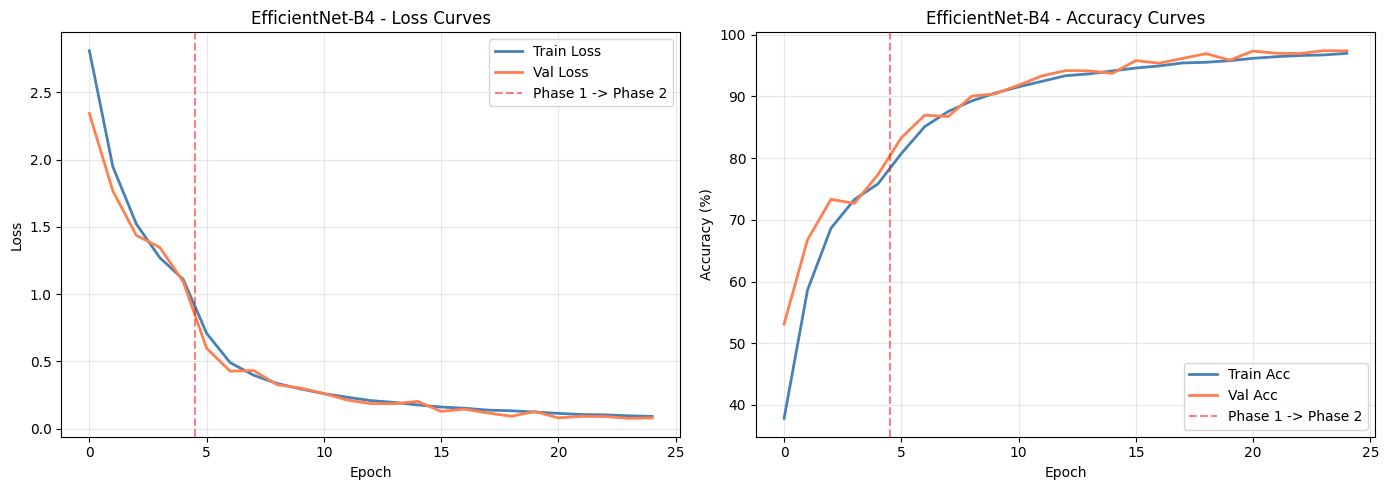


Final Train Loss: 0.0915
Final Val Loss: 0.0798
Final Train Acc: 96.99%
Final Val Acc: 97.40%
Best Val Acc: 97.42%
Saved to: /Users/hnq/Desktop/licenta/cod_plante/models/n04_efficientnet_b4_final.pth


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train Loss', linewidth=2, color='steelblue')
axes[0].plot(val_losses, label='Val Loss', linewidth=2, color='coral')
axes[0].axvline(x=PHASE1_EPOCHS - 0.5, color='red', linestyle='--', alpha=0.5, label='Phase 1 -> Phase 2')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('EfficientNet-B4 - Loss Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accs, label='Train Acc', linewidth=2, color='steelblue')
axes[1].plot(val_accs, label='Val Acc', linewidth=2, color='coral')
axes[1].axvline(x=PHASE1_EPOCHS - 0.5, color='red', linestyle='--', alpha=0.5, label='Phase 1 -> Phase 2')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('EfficientNet-B4 - Accuracy Curves')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('n04_loss_curves_efficientnet.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\nFinal Train Loss: {train_losses[-1]:.4f}")
print(f"Final Val Loss: {val_losses[-1]:.4f}")
print(f"Final Train Acc: {train_accs[-1]:.2f}%")
print(f"Final Val Acc: {val_accs[-1]:.2f}%")
print(f"Best Val Acc: {best_val_acc:.2f}%")
print(f"Saved to: {BEST_MODEL_FILE}")